# Termination Outcome — Step-by-Step Diagnostic

Replicates the logic of `functions/build_termination_outcome.py` step by step so that
intermediate results can be inspected at each stage.

Source of numbers for `outcome_construction_report.tex`.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)

PANEL_PATH = '../../data/output/conflict_level/conflict_panel.csv'
TERM_PATH  = '../../data/input/ucdp/UCDPConflictTerminationDataset_v4_2024_Conflict.csv'
OUT_PATH   = '../../data/output/conflict_level/conflict_cause.csv'

OUTCOME_LABEL_MAP = {
    1.0: 'Peace agreement',
    2.0: 'Ceasefire',
    3.0: 'Victory (govt)',
    4.0: 'Victory (rebels)',
    5.0: 'Low activity',
    6.0: 'Actor ceases to exist',
}

CAUSES_MAP = {
    'ongoing':               'censored',
    'Peace agreement':       'fade',
    'Ceasefire':             'fade',
    'Low activity':          'fade',
    'Victory (govt)':        'not at risk',
    'Victory (rebels)':      'not at risk',
    'Actor ceases to exist': 'not at risk',
}

STALE_GED_CUTOFF = '2022-01'

def _ym_str_to_num(s):
    try: y, m = str(s)[:7].split('-'); return int(y)*12 + int(m)-1
    except: return np.nan

def _date_to_num(s):
    dt = pd.to_datetime(s, errors='coerce')
    return np.nan if pd.isna(dt) else dt.year*12 + (dt.month-1)

---
## Load conflict panel

In [2]:
df_panel = pd.read_csv(PANEL_PATH, low_memory=False)

cl = (
    df_panel.drop_duplicates('conflict_id')
    [['conflict_id', 'country', 'isocode',
      'start_date', 'end_date', 'pax_first_date',
      'start_date_numeric', 'end_date_numeric',
      'ever_agreement', 'first_agreement_date']]
    .copy()
)

# Store originals before any modification
cl['_orig_ever_agreement']       = cl['ever_agreement']
cl['_orig_first_agreement_date'] = cl['first_agreement_date']

print(f"Conflicts: {len(cl)}   |   Panel: {df_panel['year_mo'].min()} – {df_panel['year_mo'].max()}")
print()
print("Initial ever_agreement distribution:")
print(cl['ever_agreement'].value_counts().sort_index().to_string())

Conflicts: 201   |   Panel: 1989-01 – 2024-12

Initial ever_agreement distribution:
ever_agreement
0     97
1    104


---
## Step 0 — Pre-GED fix

Agreements dated **before `start_date`** fall outside the observable GED spell.
These conflicts are reclassified as non-signers (`ever_agreement = 0`).

In [3]:
# Classify initial agreement timing
def _initial_timing(row):
    if row['ever_agreement'] == 0:
        return 'never_signed'
    if row['first_agreement_date'] < row['start_date_numeric']:
        return 'pre_ged'
    if row['first_agreement_date'] > row['end_date_numeric']:
        return 'post_ged'
    return 'during_ged'

cl['_init_timing'] = cl.apply(_initial_timing, axis=1)

print("Initial agreement timing (before any fix):")
print(cl['_init_timing'].value_counts().sort_index().to_string())
print()

pre_ged = cl[cl['_init_timing'] == 'pre_ged'].copy()
pre_ged['months_before_onset'] = (pre_ged['start_date_numeric'] - pre_ged['first_agreement_date']).astype(int)
print(f"Pre-GED conflicts (N={len(pre_ged)}):")
display(
    pre_ged[['conflict_id', 'country', 'start_date', 'end_date', 'pax_first_date', 'months_before_onset']]
    .sort_values('months_before_onset', ascending=False)
    .reset_index(drop=True)
)

# Apply fix
cl.loc[cl['_init_timing'] == 'pre_ged', 'ever_agreement']       = 0
cl.loc[cl['_init_timing'] == 'pre_ged', 'first_agreement_date'] = 0

print(f"ever_agreement after Step 0:  0 → {(cl['ever_agreement']==0).sum()},  1 → {(cl['ever_agreement']==1).sum()}")

Initial agreement timing (before any fix):
_init_timing
during_ged      82
never_signed    97
post_ged        11
pre_ged         11

Pre-GED conflicts (N=11):


,conflict_id,country,start_date,end_date,pax_first_date,months_before_onset
0,274,India,2020-06,2020-08,1993-09-01,321
1,11345,South Sudan,2011-08,2024-08,2006-01-01,67
2,416,Central African Republic,2001-05,2024-12,1997-01-01,52
3,402,Yemen (North Yemen),1994-02,1994-07,1990-04-01,46
4,329,Ethiopia,1993-10,2018-01,1991-07-01,27
5,230,Yemen (North Yemen),2009-11,2024-12,2008-02-01,21
6,390,Bosnia-Herzegovina,1992-04,1995-09,1991-09-01,7
7,11344,Sudan,2011-05,2011-06,2011-01-01,4
8,388,Azerbaijan,1991-12,2023-12,1991-09-01,3
9,13306,Ukraine,2014-08,2022-02,2014-06-01,2


ever_agreement after Step 0:  0 → 108,  1 → 93


---
## Termination dataset — extract last episode per conflict

The UCDP Conflict Termination Dataset has one row per (conflict_id, year).
We take the **row with the maximum year** per conflict_id:
- `c_epterm = 1` on terminal rows → `c_ependdate` and `c_outcome` populated
- `c_epterm = 0` or NaN → last episode still open → `c_ependdate = NaN`

In [4]:
df_term = pd.read_csv(TERM_PATH, low_memory=False)

last_term = (
    df_term[df_term['conflict_id'].isin(cl['conflict_id'].unique())]
    .sort_values(['conflict_id', 'year'])
    .drop_duplicates('conflict_id', keep='last')
    [['conflict_id', 'year', 'c_ependdate', 'c_outcome', 'c_epterm']]
    .rename(columns={
        'year':        'year_term_out',
        'c_ependdate': 'c_ependdate_term_out',
        'c_outcome':   'c_outcome_term_out',
        'c_epterm':    'c_epterm_term_out',
    })
)
last_term['c_ependdate_term_out'] = last_term['c_ependdate_term_out'].replace(' ', np.nan)

n_ongoing = last_term['c_ependdate_term_out'].isna().sum()
n_term    = last_term['c_ependdate_term_out'].notna().sum()

print(f"Conflicts covered: {len(last_term)}")
print(f"  Last episode ongoing    (c_ependdate = NaN):   {n_ongoing}")
print(f"  Last episode terminated (c_ependdate filled): {n_term}")
print()
print("Termination outcome — terminated last episodes:")
print(
    last_term[last_term['c_ependdate_term_out'].notna()]
    ['c_outcome_term_out'].map(OUTCOME_LABEL_MAP).value_counts().to_string()
)

Conflicts covered: 201
  Last episode ongoing    (c_ependdate = NaN):   73
  Last episode terminated (c_ependdate filled): 128

Termination outcome — terminated last episodes:
c_outcome_term_out
Low activity             47
Victory (govt)           27
Peace agreement          18
Ceasefire                16
Victory (rebels)         10
Actor ceases to exist    10


---
## Merge and convert dates to numeric index

In [5]:
cl = cl.merge(last_term, on='conflict_id', how='left')

cl['_term_numeric']    = cl['c_ependdate_term_out'].apply(_date_to_num)
cl['_ged_end_numeric'] = cl['end_date'].apply(_ym_str_to_num)
cl['end_year_ged']     = cl['end_date'].str[:4].astype(int)
cl['end_year_term']    = pd.to_datetime(cl['c_ependdate_term_out'], errors='coerce').dt.year

has_ep = cl['end_year_term'].notna()
match  = has_ep & (cl['end_year_ged'] == cl['end_year_term'])
ged_gt = has_ep & (cl['end_year_ged'] >  cl['end_year_term'])

print("GED end vs Termination end:")
print(f"  No termination endpoint (ongoing):     {(~has_ep).sum():3d}  → label 'ongoing'")
print(f"  Years MATCH  (GED == term):            {match.sum():3d}  → c_outcome label")
print(f"  Years NO MATCH (GED > term):           {ged_gt.sum():3d}  → c_outcome label + spell truncated")
print()
nm = cl[ged_gt].copy()
nm['year_gap'] = nm['end_year_ged'] - nm['end_year_term']
print("Non-matching — c_outcome distribution:")
print(nm['c_outcome_term_out'].map(OUTCOME_LABEL_MAP).value_counts().to_string())
print(f"\nYear gap: mean={nm['year_gap'].mean():.1f}, median={nm['year_gap'].median():.0f}, max={nm['year_gap'].max():.0f}")

GED end vs Termination end:
  No termination endpoint (ongoing):      73  → label 'ongoing'
  Years MATCH  (GED == term):             60  → c_outcome label
  Years NO MATCH (GED > term):            68  → c_outcome label + spell truncated

Non-matching — c_outcome distribution:
c_outcome_term_out
Low activity             34
Ceasefire                11
Peace agreement           9
Victory (govt)            8
Actor ceases to exist     5
Victory (rebels)          1

Year gap: mean=6.9, median=4, max=35


---
## Step 5 — Competing-event fix (signers only)

For each remaining signer, compare `first_agreement_date` vs `_term_numeric`:
- `c_ependdate = NaN` (episode ongoing) → **keep as signer**
- `first_agreement_date > c_ependdate` (month-level) → **reclassify as non-signer**
- `first_agreement_date ≤ c_ependdate` → **keep as signer** (same-month = signing wins)

In [6]:
signers = cl[cl['ever_agreement'] == 1].copy()

has_term       = signers['_term_numeric'].notna()
competing_wins = has_term & (signers['first_agreement_date'] > signers['_term_numeric'])
signing_wins   = has_term & (signers['first_agreement_date'] <= signers['_term_numeric'])
no_term        = ~has_term

print(f"Signers after Step 0: {len(signers)}")
print(f"  c_ependdate NaN (ongoing) → keep as signer:             {no_term.sum():3d}")
print(f"  first_agreement_date ≤ c_ependdate → signing wins:      {signing_wins.sum():3d}")
print(f"  first_agreement_date > c_ependdate → reclassify:        {competing_wins.sum():3d}")

if competing_wins.sum() > 0:
    print()
    print("Conflicts reclassified (competing event first):")
    display(signers[competing_wins][['conflict_id', 'country', 'pax_first_date', 'c_ependdate_term_out', 'c_outcome_term_out']])

# Apply fix
competing_wins_mask = (
    (cl['ever_agreement'] == 1) &
    cl['_term_numeric'].notna() &
    (cl['first_agreement_date'] > cl['_term_numeric'])
)
cl.loc[competing_wins_mask, 'ever_agreement']       = 0
cl.loc[competing_wins_mask, 'first_agreement_date'] = 0

print(f"\never_agreement after Step 5:  0 → {(cl['ever_agreement']==0).sum()},  1 → {(cl['ever_agreement']==1).sum()}")

Signers after Step 0: 93
  c_ependdate NaN (ongoing) → keep as signer:              31
  first_agreement_date ≤ c_ependdate → signing wins:       62
  first_agreement_date > c_ependdate → reclassify:          0

ever_agreement after Step 5:  0 → 108,  1 → 93


---
## Step 6 — Assign termination outcome and effective spell endpoint (non-signers)

| Condition | `termination_outcome_label` | `effective_end_date` |
|---|---|---|
| `c_ependdate = NaN` | `'ongoing'` | `end_date` |
| GED end ≤ term end | c_outcome label | `end_date` |
| GED end > term end | c_outcome label | `c_ependdate` (**spell truncated**) |

In [7]:
non_signer_mask = cl['ever_agreement'] == 0

def _assign_nonsigner(row):
    term_num  = row['_term_numeric']
    ged_num   = row['_ged_end_numeric']
    c_outcome = row['c_outcome_term_out']
    end_date  = row['end_date']
    if pd.isna(term_num):
        return pd.Series({'termination_outcome_label': 'ongoing', 'effective_end_date': end_date})
    label = OUTCOME_LABEL_MAP.get(c_outcome, 'ongoing') if not pd.isna(c_outcome) else 'ongoing'
    if ged_num <= term_num:
        return pd.Series({'termination_outcome_label': label, 'effective_end_date': end_date})
    else:
        term_ym = pd.to_datetime(row['c_ependdate_term_out']).strftime('%Y-%m')
        return pd.Series({'termination_outcome_label': label, 'effective_end_date': term_ym})

results = cl[non_signer_mask].apply(_assign_nonsigner, axis=1)

cl['termination_outcome_label'] = None
cl['effective_end_date']        = cl['end_date']
cl.loc[non_signer_mask, 'termination_outcome_label'] = results['termination_outcome_label'].values
cl.loc[non_signer_mask, 'effective_end_date']        = results['effective_end_date'].values

truncated = non_signer_mask & (cl['effective_end_date'] != cl['end_date'])
print(f"Non-signers: {non_signer_mask.sum()}")
print(f"  Spell unchanged: {(~truncated & non_signer_mask).sum()}")
print(f"  Spell TRUNCATED (effective_end_date < end_date): {truncated.sum()}")
print()
print("termination_outcome_label distribution (non-signers):")
print(cl.loc[non_signer_mask, 'termination_outcome_label'].value_counts().sort_index().to_string())

Non-signers: 108
  Spell unchanged: 74
  Spell TRUNCATED (effective_end_date < end_date): 34

termination_outcome_label distribution (non-signers):
termination_outcome_label
Actor ceases to exist     7
Ceasefire                 3
Low activity             28
Peace agreement           2
Victory (govt)           20
Victory (rebels)          6
ongoing                  42


---
## Step 6b — Stale cessation override

Non-signers with `termination_outcome_label = 'ongoing'` (c\_ependdate = NaN) whose last GED
event predates `STALE_GED_CUTOFF = 2022-01` are reclassified to `'Low activity'`.
Extended absence of GED activity without a recorded termination indicates silent cessation.

In [34]:
stale_cutoff_num = _ym_str_to_num(STALE_GED_CUTOFF)

stale_mask = (
    non_signer_mask &
    (cl['termination_outcome_label'] == 'ongoing') &
    (cl['_ged_end_numeric'] < stale_cutoff_num)
)

print(f"Stale conflicts reclassified (ongoing → Low activity): {stale_mask.sum()}")
if stale_mask.sum() > 0:
    display(
        cl[stale_mask][['conflict_id', 'country', 'start_date', 'end_date',
                        '_orig_ever_agreement', 'c_ependdate_term_out']]
        .assign(note=lambda d: d['_orig_ever_agreement'].map({0:'never signed', 1:'pre-GED signer'}))
        .drop(columns='_orig_ever_agreement')
        .reset_index(drop=True)
    )

cl.loc[stale_mask, 'termination_outcome_label'] = 'Low activity'

print()
print("termination_outcome_label after Step 6b (non-signers):")
print(cl.loc[non_signer_mask, 'termination_outcome_label'].value_counts().sort_index().to_string())

Stale conflicts reclassified (ongoing → Low activity): 3


,conflict_id,country,start_date,end_date,c_ependdate_term_out,note
0,370,Romania,1989-12,1989-12,NaN,never signed
1,389,Bosnia-Herzegovina,1992-04,1995-12,NaN,pre-GED signer
2,11344,Sudan,2011-05,2011-06,NaN,pre-GED signer



termination_outcome_label after Step 6b (non-signers):
termination_outcome_label
Actor ceases to exist     7
Ceasefire                 3
Low activity             31
Peace agreement           2
Victory (govt)           20
Victory (rebels)          6
ongoing                  39


---
## Step 6c — UCDP-only treated conflicts

Non-signers whose UCDP episode ended via **Peace agreement** or **Ceasefire** signed an agreement
not captured by PA-X. Reclassify as treated:
- `ever_agreement = 1`
- `first_agreement_date = _term_numeric` (UCDP termination month)
- `effective_end_date = c_ependdate`

In [35]:
ucdp_treated_mask = (
    non_signer_mask &
    cl['termination_outcome_label'].isin(['Peace agreement', 'Ceasefire'])
)

print(f"UCDP-only treated conflicts (Step 6c): {ucdp_treated_mask.sum()}")
if ucdp_treated_mask.sum() > 0:
    display(
        cl[ucdp_treated_mask][['conflict_id', 'country', 'start_date', 'end_date',
                                'termination_outcome_label', 'c_ependdate_term_out',
                                '_orig_ever_agreement']]
        .reset_index(drop=True)
    )

cl.loc[ucdp_treated_mask, 'ever_agreement']       = 1
cl.loc[ucdp_treated_mask, 'first_agreement_date'] = cl.loc[ucdp_treated_mask, '_term_numeric']
cl.loc[ucdp_treated_mask, 'effective_end_date']   = (
    pd.to_datetime(cl.loc[ucdp_treated_mask, 'c_ependdate_term_out']).dt.strftime('%Y-%m')
)

print(f"\never_agreement after Step 6c:  0 → {(cl['ever_agreement']==0).sum()},  1 → {(cl['ever_agreement']==1).sum()}")

UCDP-only treated conflicts (Step 6c): 5


,conflict_id,country,start_date,end_date,termination_outcome_label,c_ependdate_term_out,_orig_ever_agreement
0,274,India,2020-06,2020-08,Ceasefire,2020-12-31,1
1,292,Peru,1989-01,2023-09,Ceasefire,2010-12-30,0
2,390,Bosnia-Herzegovina,1992-04,1995-09,Peace agreement,1995-09-06,1
3,11348,Sudan,2012-03,2014-11,Peace agreement,2012-12-26,0
4,14074,Somalia,2016-07,2024-08,Ceasefire,2018-11-05,0



ever_agreement after Step 6c:  0 → 103,  1 → 98


---
## Final labels: `cause_label` and `agree_timing`

In [36]:
# cause_label
cl['cause_label'] = np.where(
    cl['ever_agreement'] == 1,
    'first_agreement',
    cl['termination_outcome_label'].map(CAUSES_MAP)
)

# Diagnostic fill: termination_outcome_label for signers (from UCDP c_outcome)
signer_mask = cl['ever_agreement'] == 1
cl.loc[signer_mask, 'termination_outcome_label'] = (
    cl.loc[signer_mask, 'c_outcome_term_out']
    .map(OUTCOME_LABEL_MAP)
    .fillna('ongoing')
)

# agree_timing
def _classify_timing(row):
    orig_ea  = row['_orig_ever_agreement']
    orig_fad = row['_orig_first_agreement_date']
    final_ea = row['ever_agreement']
    if orig_ea == 0:
        return 'ucdp_only' if final_ea == 1 else 'never_signed'
    if orig_ea == 1 and final_ea == 0:
        return 'pre_ged' if orig_fad < row['start_date_numeric'] else 'competing_event_first'
    return 'post_ged_ongoing' if orig_fad > row['_ged_end_numeric'] else 'during_ged'

cl['agree_timing'] = cl.apply(_classify_timing, axis=1)

# Diagnostic year columns
cl['end_year_ged']  = cl['end_date'].str[:4].astype(int)
cl['end_year_term'] = pd.to_datetime(cl['c_ependdate_term_out'], errors='coerce').dt.year

print("cause_label:")
print(cl['cause_label'].value_counts().sort_index().to_string())
print()
print("agree_timing:")
print(cl['agree_timing'].value_counts().sort_index().to_string())

cause_label:
cause_label
censored           39
fade               31
first_agreement    98
not at risk        33

agree_timing:
agree_timing
during_ged      95
never_signed    94
pre_ged          9
ucdp_only        3


---
## Breakdown table (for `outcome_construction_report.tex`)

In [37]:
print("cause_label × termination_outcome_label (non-signers):")
ns = cl[cl['cause_label'] != 'first_agreement']
display(
    ns.groupby(['cause_label','termination_outcome_label'], dropna=False)['conflict_id']
    .nunique().rename('n').reset_index()
    .sort_values(['cause_label','n'], ascending=[True, False])
    .reset_index(drop=True)
)

# Case counts for TikZ figures
def _ym(s):
    try: y,m=str(s)[:7].split('-'); return int(y)*12+int(m)-1
    except: return float('nan')

cl['_ged_end_num'] = cl['end_date'].apply(_ym)
case1  = (cl['cause_label']=='first_agreement') & (cl['agree_timing']=='during_ged')
case2  = (cl['cause_label']=='first_agreement') & (cl['agree_timing'].isin(['post_ged_ongoing','ucdp_only']))
non_sig = cl['cause_label'] != 'first_agreement'
trunc   = cl['effective_end_date'] != cl['end_date']
case3a  = non_sig & trunc
case3b  = non_sig & ~trunc & (cl['cause_label'] != 'censored')
case4   = cl['cause_label'] == 'censored'

print("\n=== Case counts for TikZ figures ===")
print(f"Case 1 — Signer, during GED:                 N={case1.sum()}")
print(f"Case 2 — Signer, post-GED / ucdp_only:       N={case2.sum()}")
print(f"Case 3 — Non-signer, competing exit:          N={case3a.sum()+case3b.sum()}")
print(f"         truncated (GED > term):              N={case3a.sum()}")
print(f"         non-truncated (GED ≤ term):          N={case3b.sum()}")
print(f"Case 4 — Censored (ongoing):                  N={case4.sum()}")
print(f"Total:                                        N={len(cl)}")

cause_label × termination_outcome_label (non-signers):


,cause_label,termination_outcome_label,n
0,censored,ongoing,39
1,fade,Low activity,31
2,not at risk,Victory (govt),20
3,not at risk,Actor ceases to exist,7
4,not at risk,Victory (rebels),6



=== Case counts for TikZ figures ===
Case 1 — Signer, during GED:                 N=95
Case 2 — Signer, post-GED / ucdp_only:       N=3
Case 3 — Non-signer, competing exit:          N=64
         truncated (GED > term):              N=31
         non-truncated (GED ≤ term):          N=33
Case 4 — Censored (ongoing):                  N=39
Total:                                        N=201


In [38]:
cl

,conflict_id,country,isocode,start_date,end_date,pax_first_date,start_date_numeric,end_date_numeric,ever_agreement,first_agreement_date,...,c_epterm_term_out,_term_numeric,_ged_end_numeric,end_year_ged,end_year_term,termination_outcome_label,effective_end_date,cause_label,agree_timing,_ged_end_num
0,205,Iran,IRN,1990-04,2022-11,NaN,16,407,0,0,...,1.0,24225.0,24274,2022,2018.0,Low activity,2018-10,fade,never_signed,24274
1,209,Philippines,PHL,1989-01,2024-12,1992-09-01,1,432,1,45,...,NaN,NaN,24299,2024,NaN,ongoing,2024-12,first_agreement,during_ged,24299
2,218,India,IND,1989-01,2023-11,1991-04-01,1,419,1,28,...,1.0,24251.0,24286,2023,2020.0,Ceasefire,2023-11,first_agreement,during_ged,24286
3,220,Paraguay,PRY,1989-02,1989-02,NaN,2,2,0,0,...,1.0,23869.0,23869,1989,1989.0,Victory (rebels),1989-02,not at risk,never_signed,23869
4,221,Myanmar (Burma),MMR,1989-01,2024-12,2011-11-01,1,432,1,275,...,NaN,NaN,24299,2024,NaN,ongoing,2024-12,first_agreement,during_ged,24299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,16038,Mali,MLI,2023-08,2024-12,NaN,416,432,0,0,...,NaN,NaN,24299,2024,NaN,ongoing,2024-12,censored,never_signed,24299
197,16069,Ethiopia,ETH,2023-05,2024-12,NaN,413,432,0,0,...,NaN,NaN,24299,2024,NaN,ongoing,2024-12,censored,never_signed,24299
198,16099,Yemen (North Yemen),YEM,2023-12,2024-12,NaN,420,432,0,0,...,NaN,NaN,24299,2024,NaN,ongoing,2024-12,censored,never_signed,24299
199,16292,Tajikistan,TJK,2018-07,2019-11,NaN,355,371,0,0,...,1.0,24239.0,24238,2019,2019.0,Low activity,2019-11,fade,never_signed,24238


---
## Spell panel — survival analysis risk set

One horizontal line per conflict. Spell runs from `start_date` to `first_agreement_date` (signers) or `effective_end_date` (all others). Coloured by `cause_label`.

In [40]:

import os
import sys



utils_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '2_data_analysis', 'utils')
)
sys.path.append(utils_path)
import plot_style


# Palette
C_AGR   = '#C0392B'   # red  - with agreement
C_NOAGR = '#2C6E8A'   # blue - without agreement



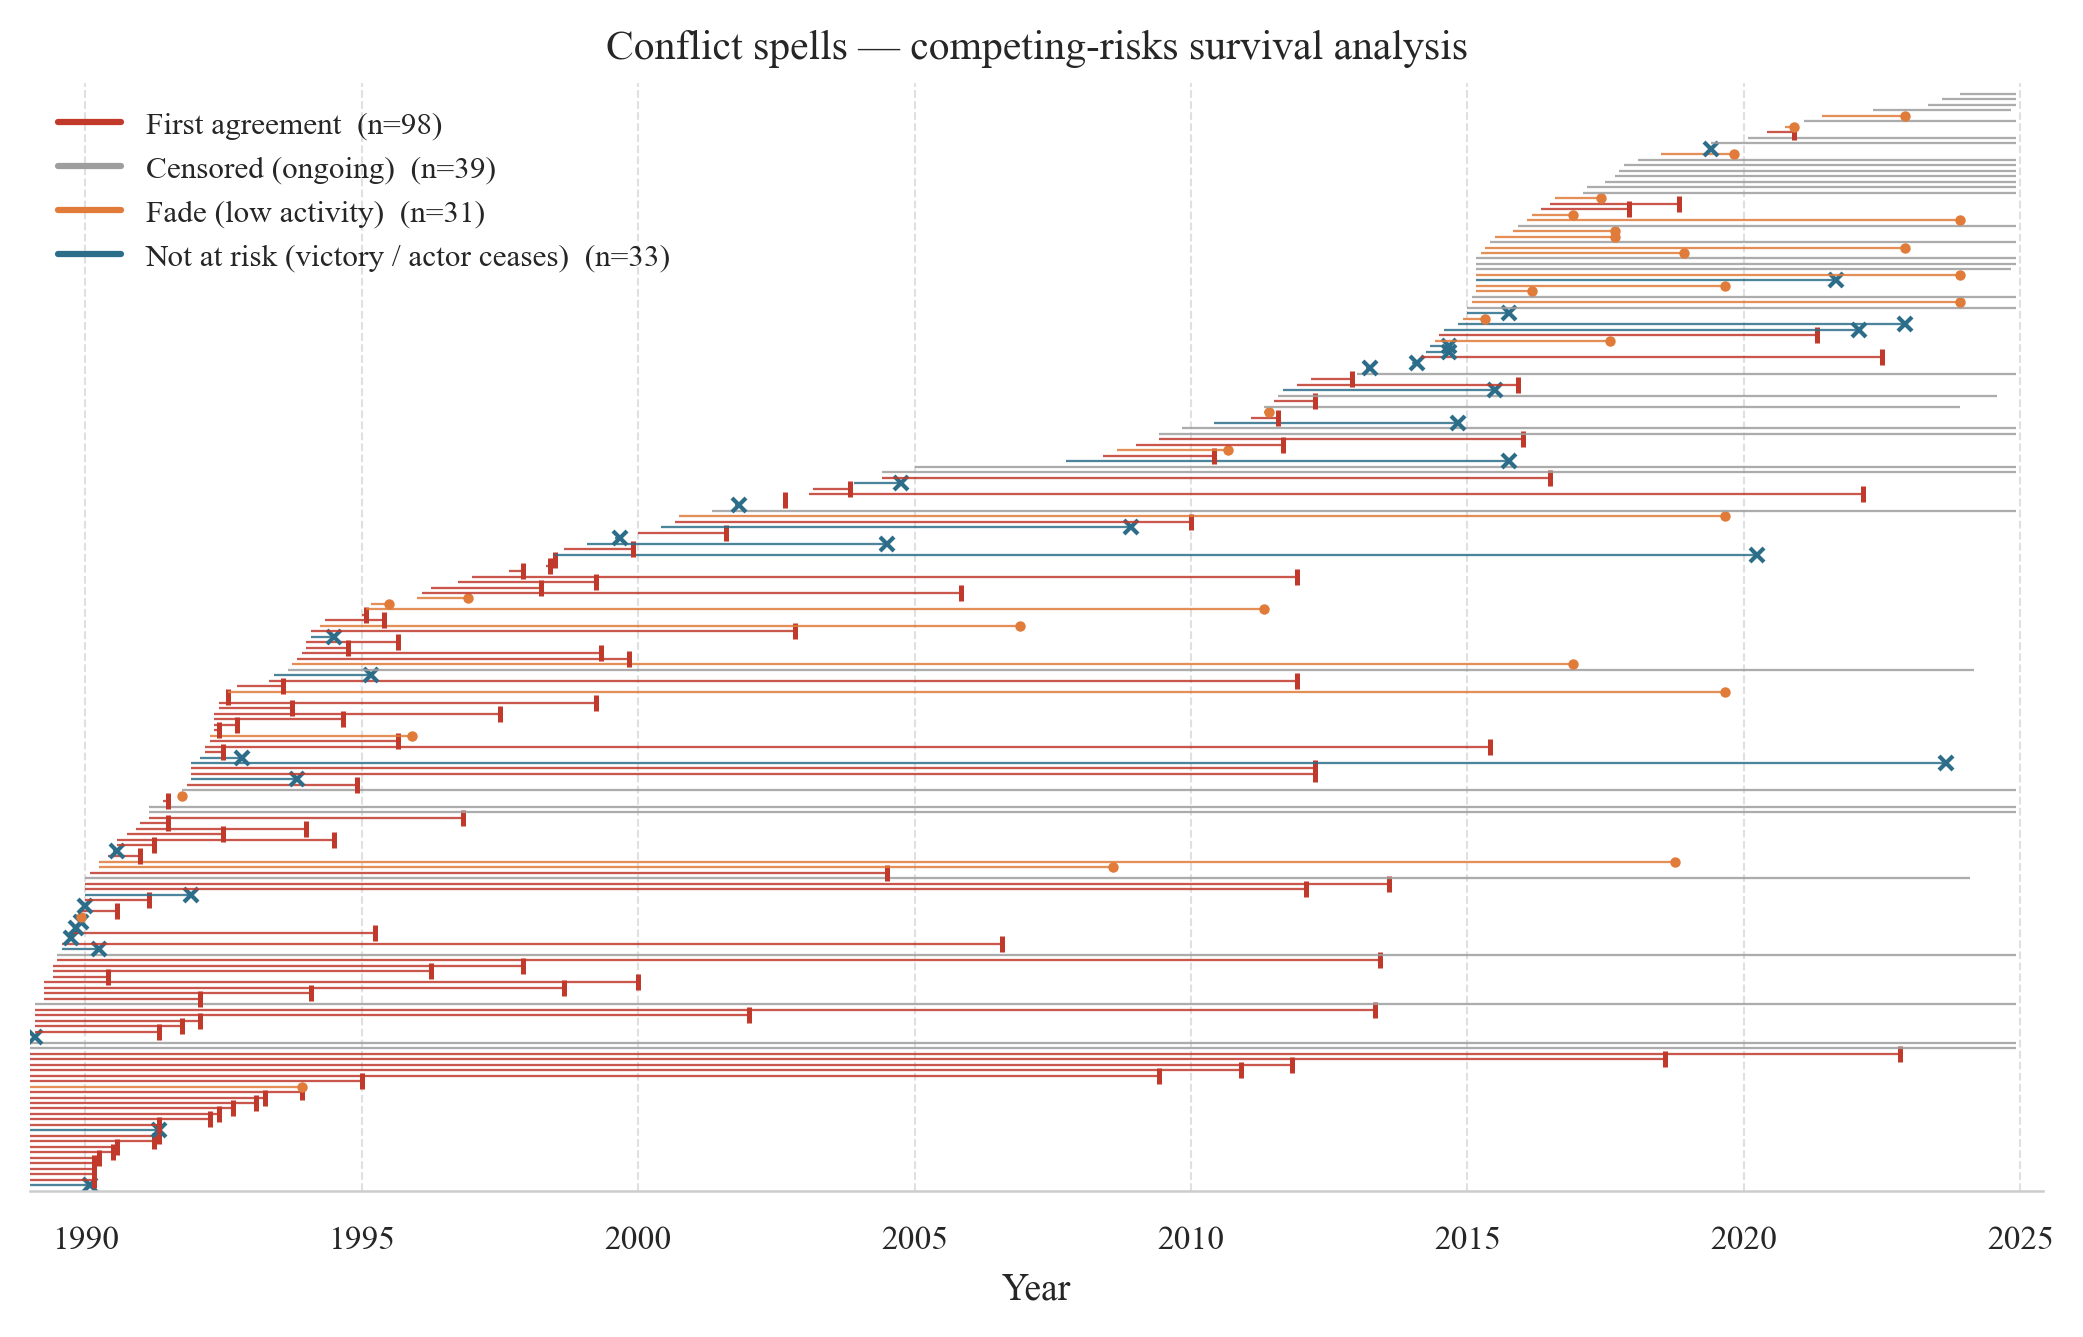

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates

# ── helpers ───────────────────────────────────────────────────────────────────
_BASE = pd.Period('1989-01', freq='M')

def _rel_num_to_ts(n):
    # relative scale: n=1 → 1989-01 (same as year_mo_numeric / first_agreement_date for PA-X signers)
    return (_BASE + int(n) - 1).to_timestamp()

def _ym_to_ts(s):
    try:
        return pd.Timestamp(str(s)[:7] + '-01')
    except Exception:
        return pd.NaT

# ── colour + marker scheme ────────────────────────────────────────────────────
CAUSE_STYLE = {
    'first_agreement': dict(color=C_AGR, marker='|',  ms=4.0, mew=1.2),
    'censored':        dict(color='#9E9E9E', marker=4,    ms=3.5, mew=0.0),   # →
    'fade':            dict(color='#E07B39', marker='o',  ms=2.5, mew=0.0),
    'not at risk':     dict(color=C_NOAGR, marker='x',  ms=3.5, mew=1.0),
}

LEGEND_LABELS = {
    'first_agreement': 'First agreement',
    'censored':        'Censored (ongoing)',
    'fade':            'Fade (low activity)',
    'not at risk':     'Not at risk (victory / actor ceases)',
}

# ── build plot dataframe ──────────────────────────────────────────────────────
plot_df = cl[['conflict_id', 'country', 'start_date', 'effective_end_date',
              'first_agreement_date', 'cause_label']].copy()

plot_df['start_ts'] = plot_df['start_date'].apply(_ym_to_ts)

# spell end routing:
# - PA-X signers (during_ged): first_agreement_date in relative scale (1=1989-01), values ≤ 432
# - UCDP-only reclassified (Step 6c): first_agreement_date = _term_numeric (absolute, ≈ 23000–24300)
#   effective_end_date is already set to c_ependdate (correct spell end) for these cases
# Threshold 1000 safely separates both scales; all Panel months fit in [1, 432]
def _spell_end(row):
    if row['cause_label'] == 'first_agreement' and row['first_agreement_date'] <= 1000:
        return _rel_num_to_ts(row['first_agreement_date'])
    return _ym_to_ts(row['effective_end_date'])

plot_df['spell_end_ts'] = plot_df.apply(_spell_end, axis=1)

# sort: start_date ascending, spell_end_ts ascending
plot_df = plot_df.sort_values(['start_ts', 'spell_end_ts']).reset_index(drop=True)

# ── figure ───────────────────────────────────────────────────────────────────
n = len(plot_df)
fig, ax = plt.subplots(figsize=(7, 4.5))

for i, row in plot_df.iterrows():
    style  = CAUSE_STYLE[row['cause_label']]
    color  = style['color']
    marker = style['marker']
    ax.plot(
        [row['start_ts'], row['spell_end_ts']],
        [i, i],
        color=color, linewidth=0.55, alpha=0.85, solid_capstyle='butt',
    )
    ax.plot(
        row['spell_end_ts'], i,
        marker, color=color,
        markersize=style['ms'], markeredgewidth=style['mew'],
    )

# ── axes ─────────────────────────────────────────────────────────────────────
ax.set_xlim(pd.Timestamp('1989-01-01'), pd.Timestamp('2025-06-01'))
ax.set_ylim(-1, n)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticks([])
ax.set_xlabel('Year', fontsize=9)
ax.set_title('Conflict spells — competing-risks survival analysis', fontsize=10)

# ── legend ───────────────────────────────────────────────────────────────────
counts = plot_df['cause_label'].value_counts()
handles = [
    mlines.Line2D(
        [], [], color=CAUSE_STYLE[k]['color'], linewidth=1.5,
        label=f"{LEGEND_LABELS[k]}  (n={counts.get(k, 0)})",
    )
    for k in ['first_agreement', 'censored', 'fade', 'not at risk']
]
ax.legend(handles=handles, loc='upper left', frameon=False, fontsize=7.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/spell_panel.png', dpi=160, bbox_inches='tight')
plt.show()